the solution of the tasks its in the bottom

Ali Jafar Altaweel
2240006456
7MA2

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Define the functions

In [2]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor),
                               interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()

## 2. Image sampling and quantization

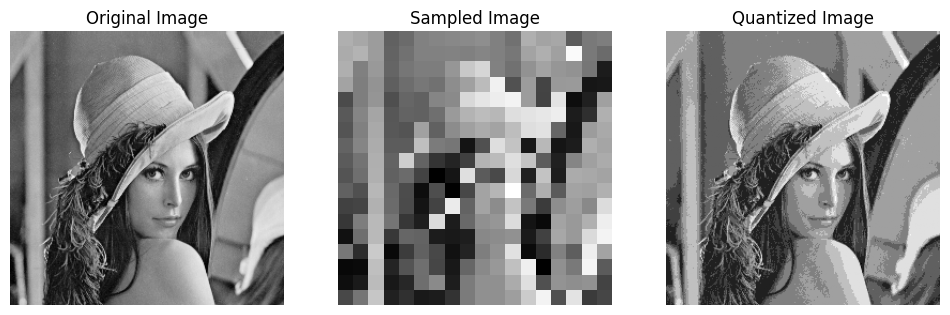

In [3]:
image_path = './images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

In [4]:
print("original  : shape =", original_image.shape,
      " pixels =", original_image.size,
      " gray levels used =", len(np.unique(original_image)))
print("sampled   : shape =", sampled_image.shape,
      " pixels =", sampled_image.size,
      " gray levels used =", len(np.unique(sampled_image)),
      f" -> {original_image.size / sampled_image.size:.1f}x fewer pixels")
print("quantized : shape =", quantized_image.shape,
      " pixels =", quantized_image.size,
      " gray levels used =", len(np.unique(quantized_image)))
print()
print("step between two gray levels (256 // 9) =", 256 // quantization_levels)
print("gray levels kept by the quantizer       :", np.unique(quantized_image))

original  : shape = (256, 256)  pixels = 65536  gray levels used = 210
sampled   : shape = (18, 18)  pixels = 324  gray levels used = 150  -> 202.3x fewer pixels
quantized : shape = (256, 256)  pixels = 65536  gray levels used = 9

step between two gray levels (256 // 9) = 28
gray levels kept by the quantizer       : [  0  28  56  84 112 140 168 196 224]


## 3. Arithmetic operations

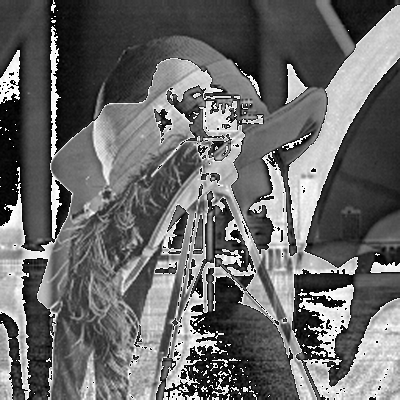

In [5]:
from PIL import Image
img1 = Image.open('./images/lena_gray_256.tif')
img2 = Image.open('./images/cameraman.tif')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
resultImage = Image.fromarray(addition)
# resultImage.show()      # <- the manual's line (external viewer)
display(resultImage)      # inline version, so the result is stored in the notebook

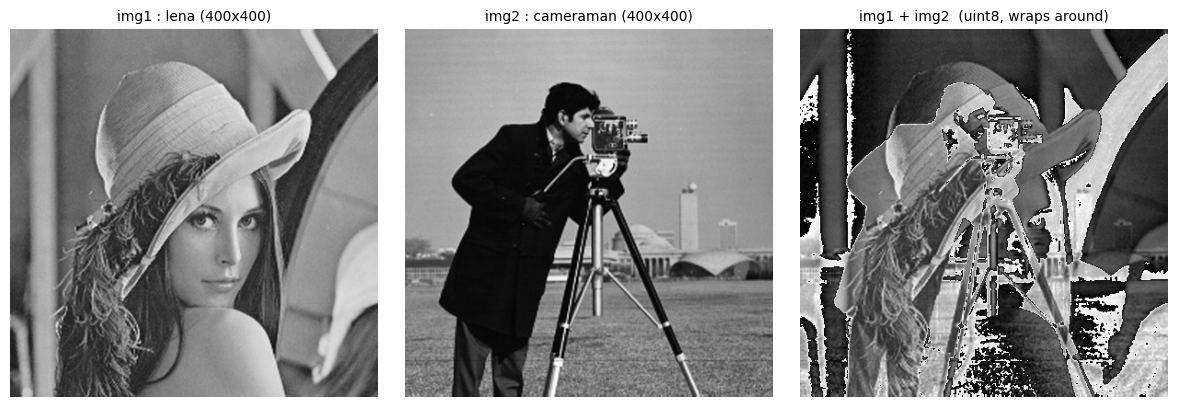

dtype of the arrays : uint8
im1arr[0,0] = 162  im2arr[0,0] = 156  -> real sum = 318  but addition[0,0] = 62
pixels whose sum exceeds 255 : 86212 / 160000


In [6]:
plt.figure(figsize=(12, 4))
for k, (im, t) in enumerate([(im1arr, 'img1 : lena (400x400)'),
                             (im2arr, 'img2 : cameraman (400x400)'),
                             (addition, 'img1 + img2  (uint8, wraps around)')]):
    plt.subplot(1, 3, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("dtype of the arrays :", im1arr.dtype)
print("im1arr[0,0] =", im1arr[0, 0], " im2arr[0,0] =", im2arr[0, 0],
      " -> real sum =", int(im1arr[0, 0]) + int(im2arr[0, 0]),
      " but addition[0,0] =", addition[0, 0])
print("pixels whose sum exceeds 255 :",
      int((im1arr.astype(np.int16) + im2arr.astype(np.int16) > 255).sum()),
      "/", im1arr.size)

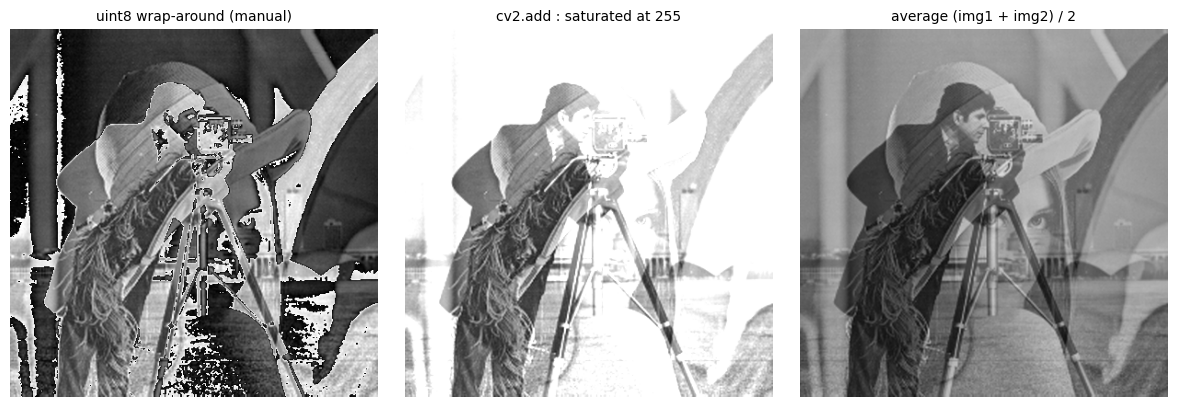

In [7]:
# (a) OpenCV saturating addition : everything above 255 is clipped to 255
addition_sat = cv2.add(im1arr, im2arr)

# (b) blending (average) : the result stays inside 0..255 by construction
blend = ((im1arr.astype(np.float64) + im2arr.astype(np.float64)) / 2).astype(np.uint8)

plt.figure(figsize=(12, 4))
for k, (im, t) in enumerate([(addition, 'uint8 wrap-around (manual)'),
                             (addition_sat, 'cv2.add : saturated at 255'),
                             (blend, 'average (img1 + img2) / 2')]):
    plt.subplot(1, 3, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Sets and logical operations

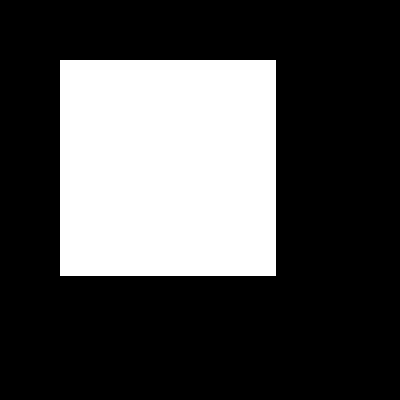

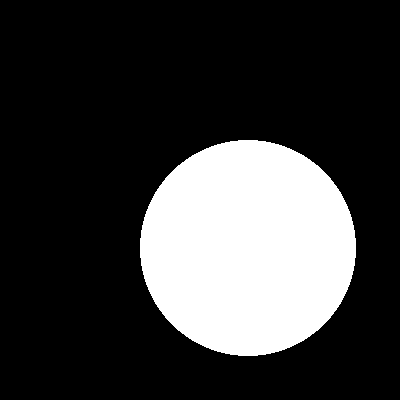

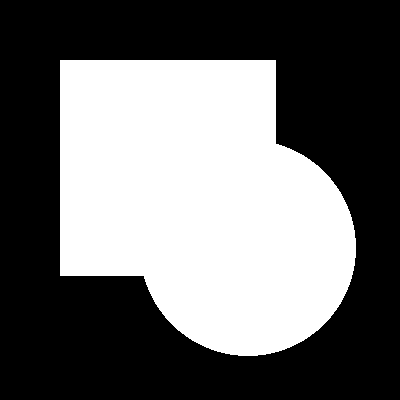

In [8]:
img3 = Image.open('./images/A.png')
display(img3)             # manual: img3.show()
img4 = Image.open('./images/B.png')
display(img4)             # manual: img4.show()

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)
# resultImage2.show()     # <- the manual's line (external viewer)
display(resultImage2)

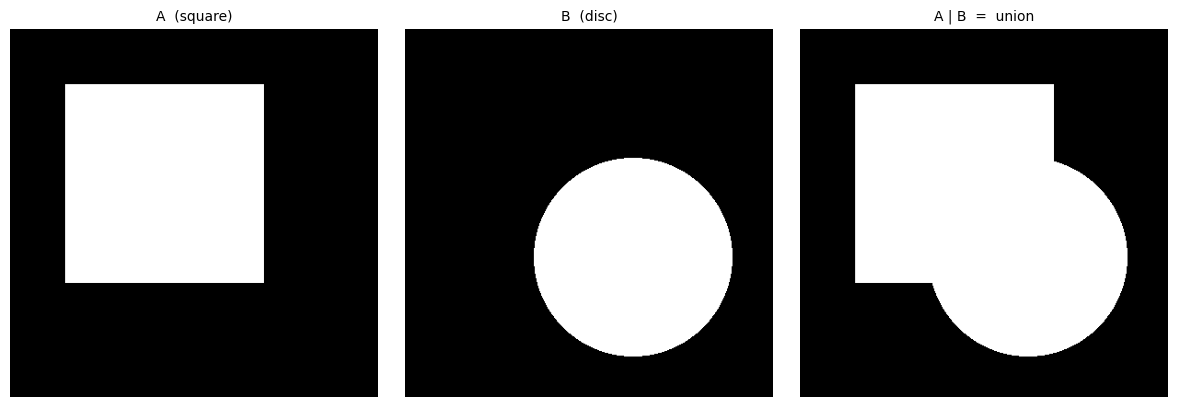

values present in A     : [  0 255]
values present in B     : [  0 255]
values present in A | B : [  0 255]
white pixels : A = 46656  B = 36608  A|B = 67348


In [9]:
plt.figure(figsize=(12, 4))
for k, (im, t) in enumerate([(im3arr, 'A  (square)'),
                             (im4arr, 'B  (disc)'),
                             (union, 'A | B  =  union')]):
    plt.subplot(1, 3, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("values present in A     :", np.unique(im3arr))
print("values present in B     :", np.unique(im4arr))
print("values present in A | B :", np.unique(union))
print("white pixels : A =", int((im3arr == 255).sum()),
      " B =", int((im4arr == 255).sum()),
      " A|B =", int((union == 255).sum()))

## 5. Student tasks

### Task 1
Change the sampling and quantization parameters and observe the effects.

### Task 2
Read two images, convert them into arrays, and perform the following operations on them.
1. Subtract two images and display the result.
2. Add one image with a constant value of 175 and display it.
3. Apply the set difference operation on two Gray-Scale images.
4. Apply the symmetric difference operation on two Gray-Scale images.
5. Apply Intersection operations on two Gray-Scale images.

### Task 1 Solution – Changing the sampling and quantization parameters

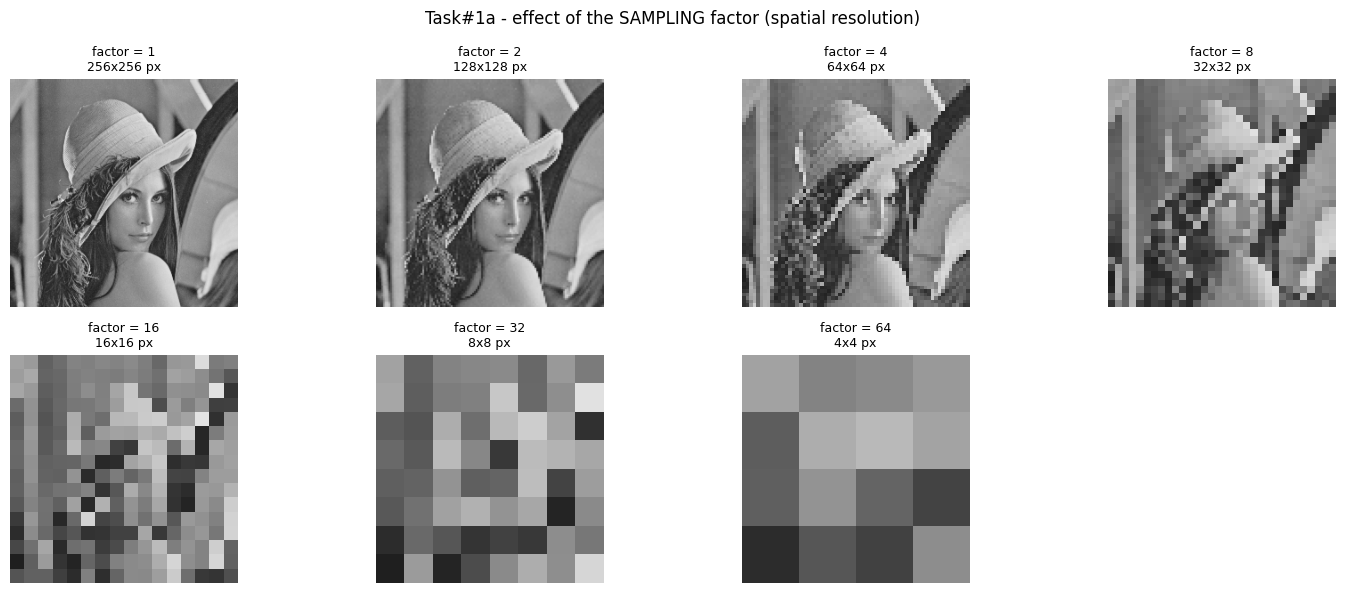

 factor |        size |  pixels |   bytes | data reduction
------------------------------------------------------------
      1 |  256x256    |   65536 |   65536 |        1.0x
      2 |  128x128    |   16384 |   16384 |        4.0x
      4 |   64x64     |    4096 |    4096 |       16.0x
      8 |   32x32     |    1024 |    1024 |       64.0x
     16 |   16x16     |     256 |     256 |      256.0x
     32 |    8x8      |      64 |      64 |     1024.0x
     64 |    4x4      |      16 |      16 |     4096.0x


In [10]:
# ---- sampling : keep 1 pixel out of every "factor" pixels ----
factors = [1, 2, 4, 8, 16, 32, 64]

plt.figure(figsize=(15, 6))
for k, f in enumerate(factors):
    s = sample_image(original_image, f)
    plt.subplot(2, 4, k + 1)
    plt.imshow(s, cmap='gray', vmin=0, vmax=255)
    plt.title(f'factor = {f}\n{s.shape[0]}x{s.shape[1]} px', fontsize=9)
    plt.axis('off')
plt.suptitle('Task#1a - effect of the SAMPLING factor (spatial resolution)')
plt.tight_layout()
plt.show()

print(f"{'factor':>7} | {'size':>11} | {'pixels':>7} | {'bytes':>7} | data reduction")
print('-' * 60)
for f in factors:
    s = sample_image(original_image, f)
    print(f"{f:>7} | {s.shape[0]:>4}x{s.shape[1]:<6} | {s.size:>7} | {s.nbytes:>7} |"
          f" {original_image.size / s.size:>10.1f}x")

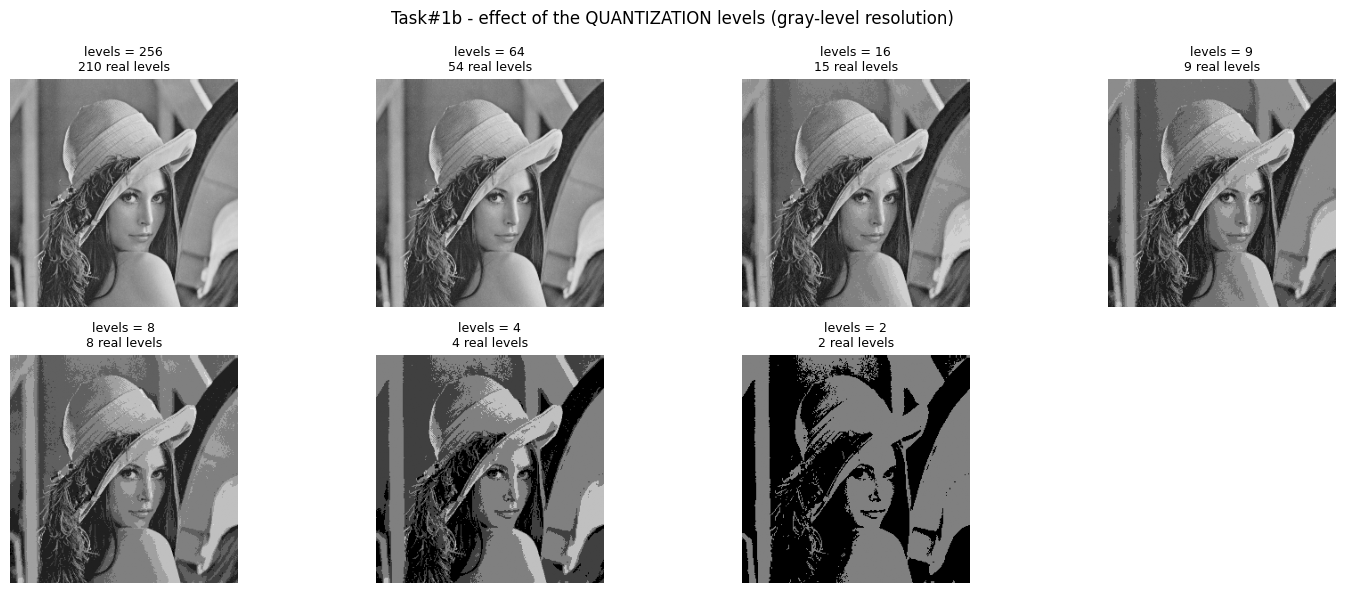

 levels |  step | real levels | bits/pixel
---------------------------------------------
    256 |     1 |         210 |          8
     64 |     4 |          54 |          6
     16 |    16 |          15 |          4
      9 |    28 |           9 |          4
      8 |    32 |           8 |          3
      4 |    64 |           4 |          2
      2 |   128 |           2 |          1


In [11]:
# ---- quantization : keep only "levels" gray levels ----
levels_list = [256, 64, 16, 9, 8, 4, 2]

plt.figure(figsize=(15, 6))
for k, L in enumerate(levels_list):
    q = quantize_image(original_image, L)
    plt.subplot(2, 4, k + 1)
    plt.imshow(q, cmap='gray', vmin=0, vmax=255)
    plt.title(f'levels = {L}\n{len(np.unique(q))} real levels', fontsize=9)
    plt.axis('off')
plt.suptitle('Task#1b - effect of the QUANTIZATION levels (gray-level resolution)')
plt.tight_layout()
plt.show()

print(f"{'levels':>7} | {'step':>5} | {'real levels':>11} | {'bits/pixel':>10}")
print('-' * 45)
for L in levels_list:
    q = quantize_image(original_image, L)
    real = len(np.unique(q))
    print(f"{L:>7} | {256 // L:>5} | {real:>11} | {np.ceil(np.log2(real)):>10.0f}")

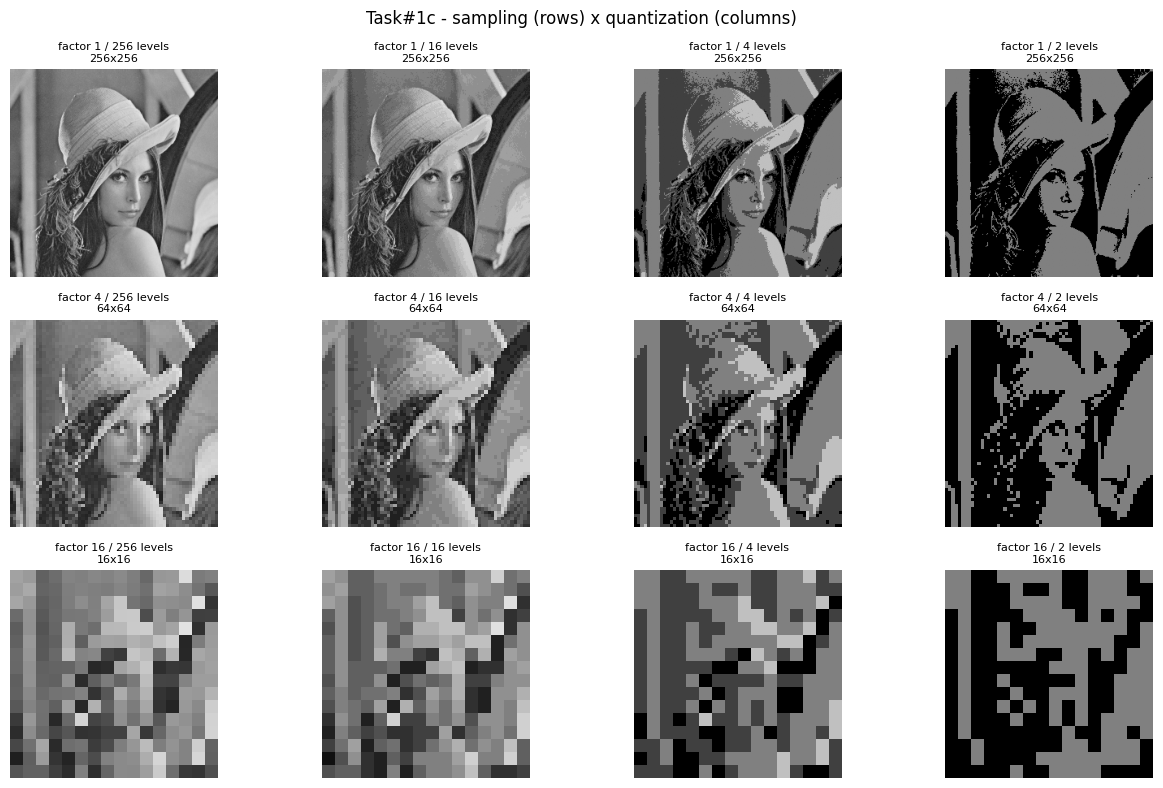

In [12]:
# ---- the two effects combined ----
plt.figure(figsize=(13, 8))
k = 1
for f in [1, 4, 16]:
    for L in [256, 16, 4, 2]:
        img_sq = quantize_image(sample_image(original_image, f), L)
        plt.subplot(3, 4, k)
        plt.imshow(img_sq, cmap='gray', vmin=0, vmax=255)
        plt.title(f'factor {f} / {L} levels\n{img_sq.shape[0]}x{img_sq.shape[1]}', fontsize=8)
        plt.axis('off')
        k += 1
plt.suptitle('Task#1c - sampling (rows) x quantization (columns)')
plt.tight_layout()
plt.show()

### Task 2 Solution – Operations on two images

In [13]:
# Read the two images and convert them into arrays (they are already 400x400)
A = im1arr        # lena
B = im2arr        # cameraman

print("A :", A.shape, A.dtype, " min/max =", A.min(), A.max())
print("B :", B.shape, B.dtype, " min/max =", B.min(), B.max())

A : (400, 400) uint8  min/max = 6 245
B : (400, 400) uint8  min/max = 0 255


#### 1. Subtract two images and display the result

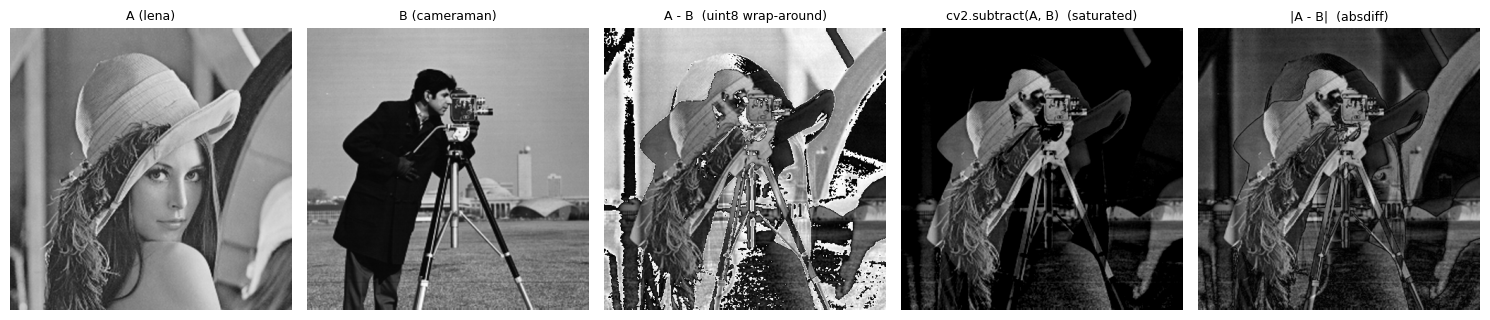

pixel [0,9] :  A = 157   B = 158   real difference = -1
A - B         : 255   (wrapped : -x becomes 256-x)
cv2.subtract  : 0   (saturated to 0)
cv2.absdiff   : 1   (absolute value)
pixels where A < B (i.e. pixels that wrap) : 76020 / 160000


In [14]:
subtraction = A - B                      # uint8 -> wraps around when the result is negative
subtraction_sat = cv2.subtract(A, B)     # saturated : negative results become 0
difference_abs = cv2.absdiff(A, B)       # absolute difference |A - B|

plt.figure(figsize=(15, 4))
for k, (im, t) in enumerate([(A, 'A (lena)'), (B, 'B (cameraman)'),
                             (subtraction, 'A - B  (uint8 wrap-around)'),
                             (subtraction_sat, 'cv2.subtract(A, B)  (saturated)'),
                             (difference_abs, '|A - B|  (absdiff)')]):
    plt.subplot(1, 5, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# take a pixel where A < B, i.e. where the true difference is negative
r, c = [int(v[0]) for v in np.nonzero(A < B)]
print(f"pixel [{r},{c}] :  A =", A[r, c], "  B =", B[r, c],
      "  real difference =", int(A[r, c]) - int(B[r, c]))
print("A - B         :", subtraction[r, c], "  (wrapped : -x becomes 256-x)")
print("cv2.subtract  :", subtraction_sat[r, c], "  (saturated to 0)")
print("cv2.absdiff   :", difference_abs[r, c], "  (absolute value)")
print("pixels where A < B (i.e. pixels that wrap) :", int((A < B).sum()), "/", A.size)

#### 2. Add one image with a constant value of 175 and display it

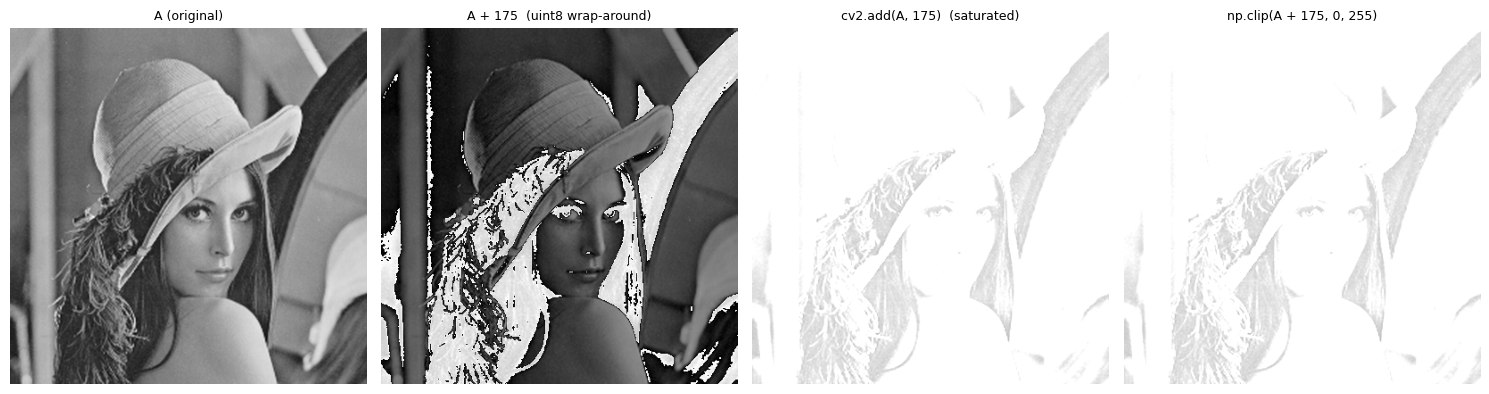

mean of A                       : 124.01
mean of A + 175 (wrapped)       : 98.62
mean of A + 175 (saturated)     : 249.63
cv2.add == np.clip              : True
pixels that exceed 255 before clipping : 125243 / 160000


In [15]:
constant = 175

add_const_wrap = A + np.uint8(constant)                      # uint8 -> wraps at 256
add_const_sat = cv2.add(A, constant)                         # saturated at 255
add_const_clip = np.clip(A.astype(np.int16) + constant, 0, 255).astype(np.uint8)   # same, NumPy

plt.figure(figsize=(15, 4))
for k, (im, t) in enumerate([(A, 'A (original)'),
                             (add_const_wrap, f'A + {constant}  (uint8 wrap-around)'),
                             (add_const_sat, f'cv2.add(A, {constant})  (saturated)'),
                             (add_const_clip, f'np.clip(A + {constant}, 0, 255)')]):
    plt.subplot(1, 4, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("mean of A                       :", round(float(A.mean()), 2))
print("mean of A + 175 (wrapped)       :", round(float(add_const_wrap.mean()), 2))
print("mean of A + 175 (saturated)     :", round(float(add_const_sat.mean()), 2))
print("cv2.add == np.clip              :", np.array_equal(add_const_sat, add_const_clip))
print("pixels that exceed 255 before clipping :",
      int((A.astype(np.int16) + constant > 255).sum()), "/", A.size)

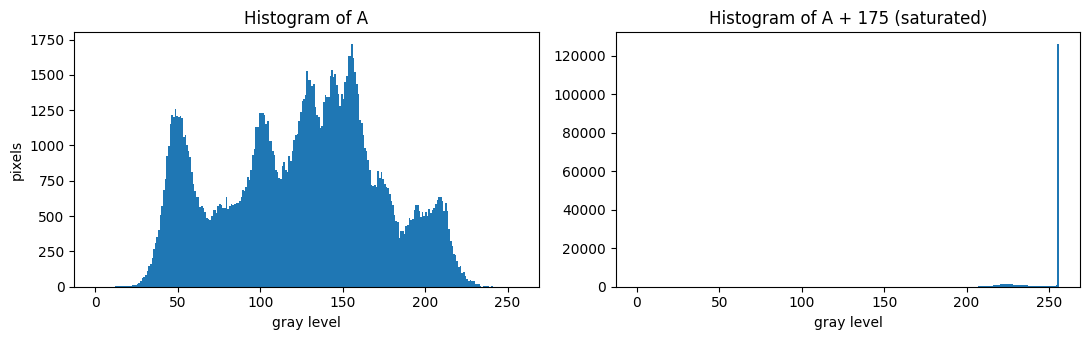

In [16]:
# the histogram explains what "adding a constant" does : it shifts the histogram to the right
plt.figure(figsize=(11, 3.5))
plt.subplot(1, 2, 1)
plt.hist(A.ravel(), bins=256, range=(0, 256))
plt.title('Histogram of A')
plt.xlabel('gray level')
plt.ylabel('pixels')
plt.subplot(1, 2, 2)
plt.hist(add_const_sat.ravel(), bins=256, range=(0, 256))
plt.title('Histogram of A + 175 (saturated)')
plt.xlabel('gray level')
plt.tight_layout()
plt.show()

#### 3. Set difference on two gray-scale images

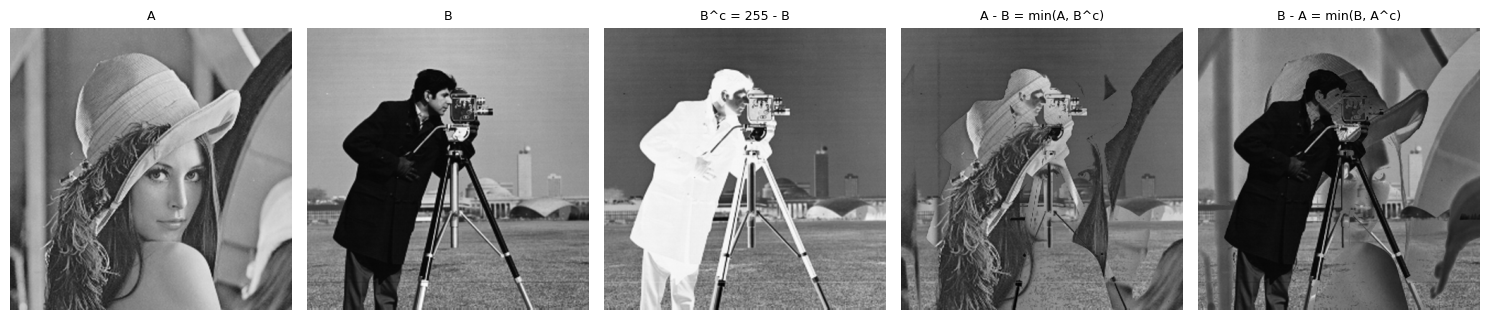

mean A     : 124.01
mean A - B : 95.37
mean B - A : 89.7
A - B differs from B - A -> the set difference is NOT commutative : True


In [17]:
B_complement = 255 - B                                   # complement of B
set_difference_AB = np.minimum(A, B_complement)          # A - B
set_difference_BA = np.minimum(B, 255 - A)               # B - A

plt.figure(figsize=(15, 4))
for k, (im, t) in enumerate([(A, 'A'), (B, 'B'), (B_complement, 'B^c = 255 - B'),
                             (set_difference_AB, 'A - B = min(A, B^c)'),
                             (set_difference_BA, 'B - A = min(B, A^c)')]):
    plt.subplot(1, 5, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("mean A     :", round(float(A.mean()), 2))
print("mean A - B :", round(float(set_difference_AB.mean()), 2))
print("mean B - A :", round(float(set_difference_BA.mean()), 2))
print("A - B differs from B - A -> the set difference is NOT commutative :",
      not np.array_equal(set_difference_AB, set_difference_BA))

#### 4. Symmetric difference on two gray-scale images

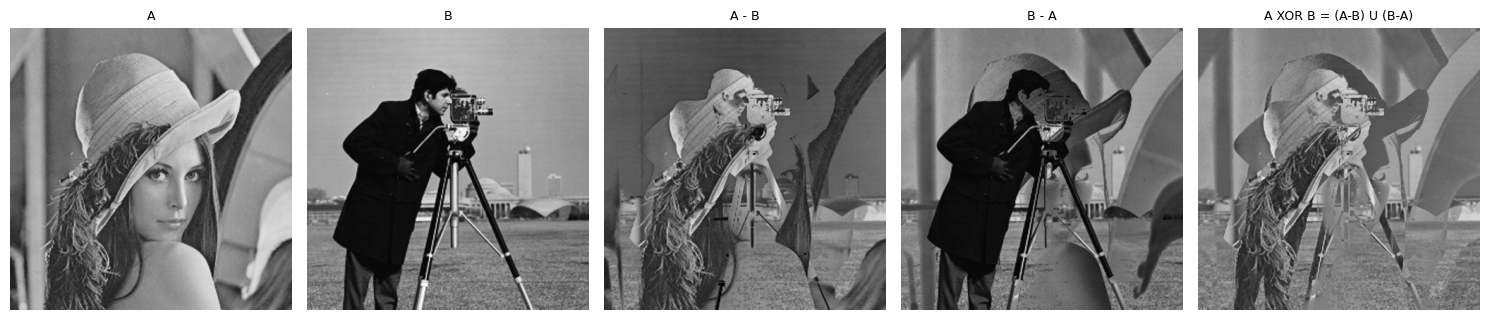

mean of the symmetric difference : 120.95
the symmetric difference IS commutative : True


In [18]:
symmetric_difference = np.maximum(set_difference_AB, set_difference_BA)

plt.figure(figsize=(15, 4))
for k, (im, t) in enumerate([(A, 'A'), (B, 'B'),
                             (set_difference_AB, 'A - B'),
                             (set_difference_BA, 'B - A'),
                             (symmetric_difference, 'A XOR B = (A-B) U (B-A)')]):
    plt.subplot(1, 5, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("mean of the symmetric difference :", round(float(symmetric_difference.mean()), 2))
print("the symmetric difference IS commutative :",
      np.array_equal(symmetric_difference,
                     np.maximum(set_difference_BA, set_difference_AB)))

#### 5. Intersection on two gray-scale images

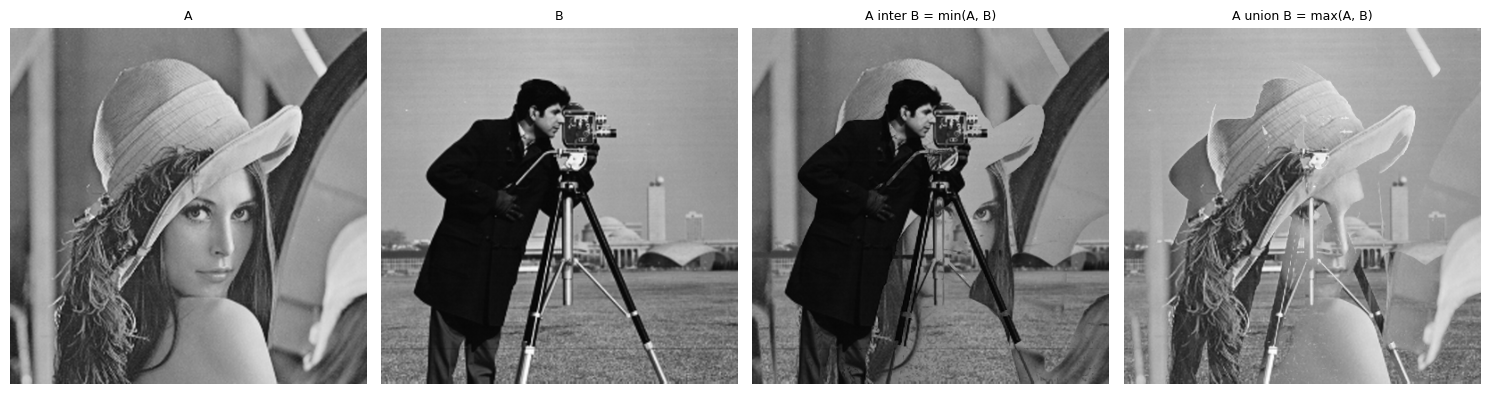

mean A            : 124.01
mean B            : 118.33
mean intersection : 92.75  (<= both means)
mean union        : 149.58  (>= both means)
check  min(A,B) + max(A,B) == A + B : True


In [19]:
intersection = np.minimum(A, B)
union_gray = np.maximum(A, B)                # union, for comparison

plt.figure(figsize=(15, 4))
for k, (im, t) in enumerate([(A, 'A'), (B, 'B'),
                             (intersection, 'A inter B = min(A, B)'),
                             (union_gray, 'A union B = max(A, B)')]):
    plt.subplot(1, 4, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("mean A            :", round(float(A.mean()), 2))
print("mean B            :", round(float(B.mean()), 2))
print("mean intersection :", round(float(intersection.mean()), 2), " (<= both means)")
print("mean union        :", round(float(union_gray.mean()), 2), " (>= both means)")
print("check  min(A,B) + max(A,B) == A + B :",
      np.array_equal(intersection.astype(int) + union_gray.astype(int),
                     A.astype(int) + B.astype(int)))

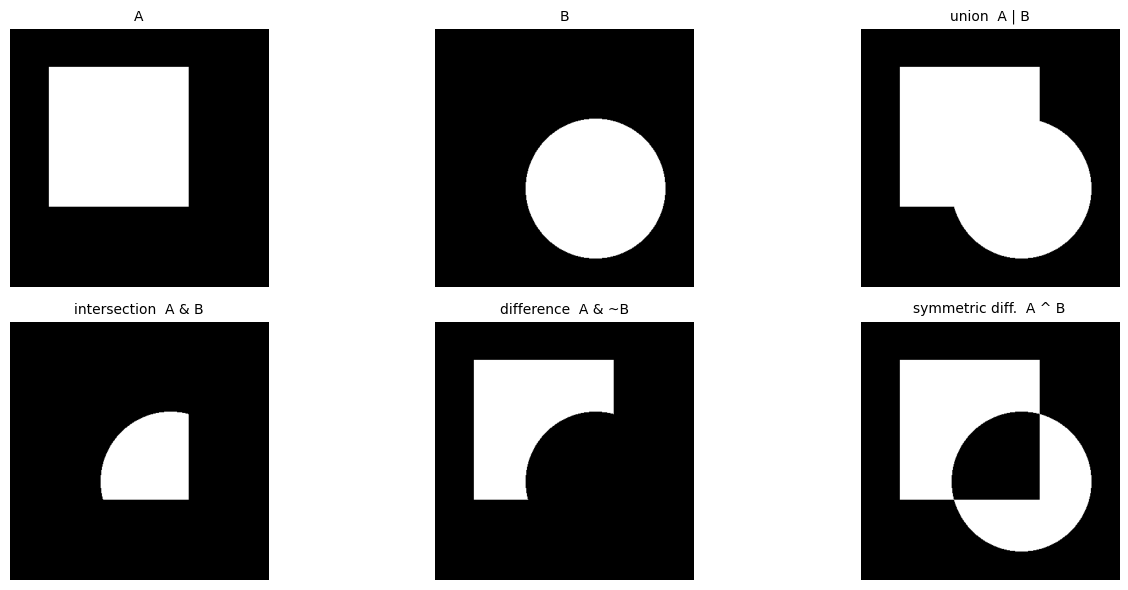

union        : |  == np.maximum          : True
intersection : &  == np.minimum          : True
difference   : A & ~B == min(A, 255-B)   : True
symmetric    : A ^ B  == max(A-B, B-A)   : True


In [20]:
Ab, Bb = im3arr, im4arr          # binary square and disc, 400x400

ops = [('A', Ab),
       ('B', Bb),
       ('union  A | B', Ab | Bb),
       ('intersection  A & B', Ab & Bb),
       ('difference  A & ~B', Ab & ~Bb),
       ('symmetric diff.  A ^ B', Ab ^ Bb)]

plt.figure(figsize=(14, 6))
for k, (t, im) in enumerate(ops):
    plt.subplot(2, 3, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

# the bitwise operators and the min / max definitions agree on binary images
print("union        : |  == np.maximum          :", np.array_equal(Ab | Bb, np.maximum(Ab, Bb)))
print("intersection : &  == np.minimum          :", np.array_equal(Ab & Bb, np.minimum(Ab, Bb)))
print("difference   : A & ~B == min(A, 255-B)   :",
      np.array_equal(Ab & ~Bb, np.minimum(Ab, 255 - Bb)))
print("symmetric    : A ^ B  == max(A-B, B-A)   :",
      np.array_equal(Ab ^ Bb, np.maximum(np.minimum(Ab, 255 - Bb),
                                         np.minimum(Bb, 255 - Ab))))

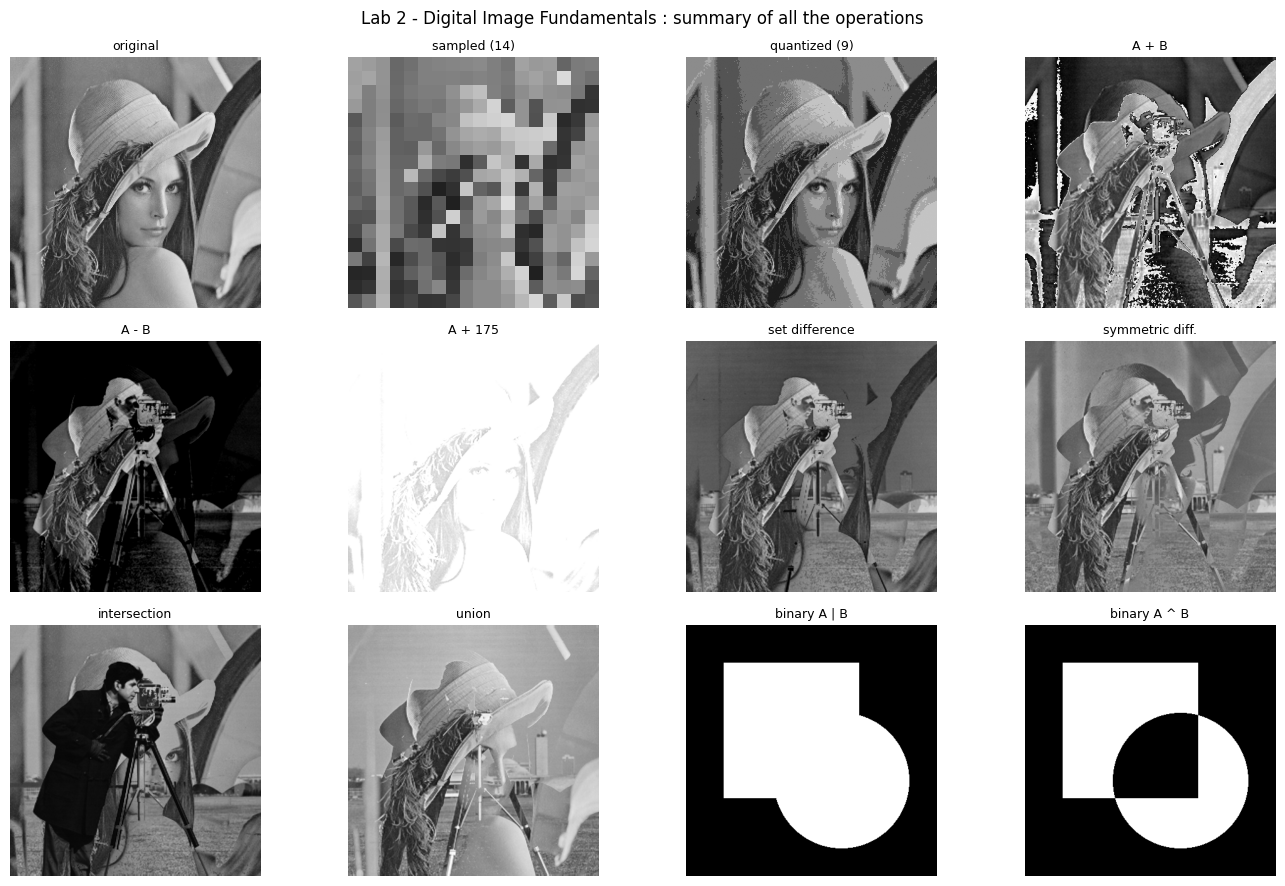

In [21]:
# ---- final summary of every operation of the lab ----
summary = [
    ('original', original_image), ('sampled (14)', sampled_image),
    ('quantized (9)', quantized_image), ('A + B', addition),
    ('A - B', subtraction_sat), ('A + 175', add_const_sat),
    ('set difference', set_difference_AB), ('symmetric diff.', symmetric_difference),
    ('intersection', intersection), ('union', union_gray),
    ('binary A | B', union), ('binary A ^ B', Ab ^ Bb),
]

plt.figure(figsize=(14, 9))
for k, (t, im) in enumerate(summary):
    plt.subplot(3, 4, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=9)
    plt.axis('off')
plt.suptitle('Lab 2 - Digital Image Fundamentals : summary of all the operations')
plt.tight_layout()
plt.show()